## This notebook allows visualizing the different DEGs from DESeq2 and analysing their effect for Lung data

In [139]:
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score,  silhouette_samples
import random

## Load Data

In [62]:
input_file = "DESeq2Local/DESeq2Input/subsetted_lung_counts_ml_model.csv"
sample_clinical_file = "Datasets/DESeq2Input/lungSampleToClinicalFeatures.csv"
sample_clinical = pd.read_csv(sample_clinical_file)

In [63]:
df = pd.read_csv(input_file)
df.index = df['gene_id']
df = df.drop('gene_id', axis = 1)

In [64]:
df

,5faf8a12-a2aa-44f1-b099-02106766ec94,6855a406-c085-45c7-b789-981786f0c775,e2445ad6-2a6a-4ec3-84d8-93cc3c180a58,4b167e70-e4e6-47f7-9fe9-11cf20f0d442,470afda8-c4a4-4161-b6e7-1f0d2372d2c7,51054c11-8e2f-4f52-bdaf-ebb515508a28,95abf543-3987-4436-ba2a-a15e9c244d77,bf456ccc-e7bb-40e0-9e92-03e6ced8564b,cab5b00a-9cf2-4e1f-b2f3-93d27b73631e,4ca257ea-95ef-4881-8ab5-cd3ee88dbb6d,...,f47f1b37-e4a3-4f87-97c5-251ec084cdd9,4a5f6af0-e0d1-4657-9bdc-85eb6c31ffbb,89bdfb20-8991-4bc4-b112-6e9be096b566,d29660d3-b3f7-4186-8c71-bebbabee600a,46ef57a2-e2ce-4ffe-9ce8-c043c6065863,6c20a899-c806-46d0-b744-a26e53a9cb45,c36f84e5-8c59-46fe-af32-7f70684383b2,4c994cf9-52d0-4c05-97c0-fd2d3ffb9100,94613d97-0a68-4212-beef-3c97a0b363ef,d1f98c65-fd27-4893-a5c5-bc0bfe16ac5f
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,1317.0,7434.0,3037.0,2538.0,1521.0,11426.0,2588.0,45901.0,2567.0,2695.0,...,1123,2121,783,2532,897,2794,706,4768,577,1438
ENSG00000000005.6,1.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,1.0,0.0,...,0,8,0,1,1,0,1,12,1,2
ENSG00000000419.13,2172.0,2968.0,3243.0,1816.0,2693.0,2428.0,3898.0,3414.0,1771.0,1091.0,...,680,1211,783,1000,735,1659,811,3692,941,1969
ENSG00000000457.14,738.0,555.0,499.0,545.0,244.0,1236.0,907.0,805.0,354.0,537.0,...,374,418,380,465,321,905,635,1417,275,911
ENSG00000000460.17,426.0,643.0,980.0,488.0,168.0,888.0,1343.0,625.0,488.0,684.0,...,92,99,72,120,55,204,104,301,36,146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288637.1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,...,2,1,0,0,0,2,0,2,1,0
ENSG00000288658.1,26.0,36.0,308.0,1.0,19.0,139.0,15.0,46.0,6.0,135.0,...,18,5,13,28,2,28,4,92,4,15
ENSG00000288669.1,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,1,0,0,1,0,0,1


In [67]:
sample_clinical.index = sample_clinical["Unnamed: 0"]
sample_clinical = sample_clinical.drop("Unnamed: 0", axis = 1)

In [68]:
sample_subset = list(df.columns)
sample_clinical = sample_clinical.loc[sample_subset]

In [69]:
sample_clinical.shape

(894, 9)

In [70]:
def plot_silhouette(sil_df):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=sil_df, x='label', y='silhouette', hue='label', palette='Set2', legend=False)
    plt.axhline(0, linestyle='--', color='gray')
    plt.title("Silhouette scores by condition/subtype")
    plt.ylabel("Silhouette value")
    plt.xlabel("Label")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Gene Subsets and Visualizations

In [333]:
base_dir = Path("DESeq2Local/results/DiseaseType_Subset_Lung/CancerToNormal")
all_cancer_to_normal_sig_genes = set()

In [334]:
for subfolder in base_dir.iterdir():
    if subfolder.is_dir():
        sig_file = subfolder / "sig_genes.csv"
        if sig_file.exists():
            df_genes = pd.read_csv(sig_file, index_col=0)  # assuming gene names are rownames
            print(len(df_genes))
            all_cancer_to_normal_sig_genes.update(df_genes.index.tolist())


7203
5491


In [328]:
len(all_cancer_to_normal_sig_genes)

9102

In [335]:
base_dir = Path("DESeq2Local/results/DiseaseType_Subset_Lung/CancerSTtoST")
all_cancer_to_cancer_sig_genes = set()

In [336]:
for subfolder in base_dir.iterdir():
    if subfolder.is_dir():
        sig_file = subfolder / "sig_genes.csv"
        if sig_file.exists():
            df_genes = pd.read_csv(sig_file, index_col=0)  # assuming gene names are rownames
            print(len(df_genes))
            all_cancer_to_cancer_sig_genes.update(df_genes.index.tolist())


3518


In [77]:
len(all_cancer_to_cancer_sig_genes)

3518

In [78]:
intersection_sig_genes = all_cancer_to_normal_sig_genes.intersection(all_cancer_to_cancer_sig_genes)
len(intersection_sig_genes)

3149

In [79]:
union_sig_genes = all_cancer_to_normal_sig_genes.union(all_cancer_to_cancer_sig_genes)
len(union_sig_genes)

8633

In [80]:
columns_to_group_dict = {
    'Gender' : 'demographic.gender',
    'Age': 'demographic.age_at_index',
    'Race': 'demographic.race',
    'Disease Type' : 'cases.disease_type',
    # 'Pathologic Stage': 'diagnoses.ajcc_pathologic_stage',
    # 'Classification of Tumor' :'diagnoses.classification_of_tumor',
    # 'Primary Diagnosis': 'diagnoses.primary_diagnosis',
}

In [276]:
def save_pca_plot(pca_df, explained, hue, title, filename, save = True):
    plt.figure(figsize=(8, 6))
    scatter = sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=hue, palette='Set2', s=60)
    plt.xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    box = scatter.get_position()
    scatter.set_position([box.x0, box.y0, box.width * 0.8, box.height])  # Shrink plot
    plt.legend(
        title='Categories',
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.,
        ncol=2,  # Two-column legend
        fontsize='small',
        title_fontsize='medium'
    )
    if save: 
        plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

## All genes

In [82]:
df_for_pca = df.T
log_norm_df = np.log2(df_for_pca + 1)

In [83]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

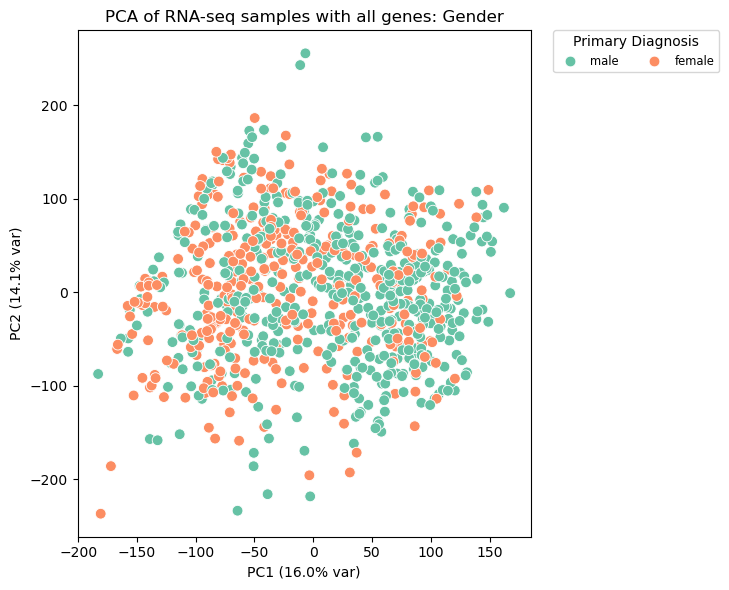

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_47294/761855078.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


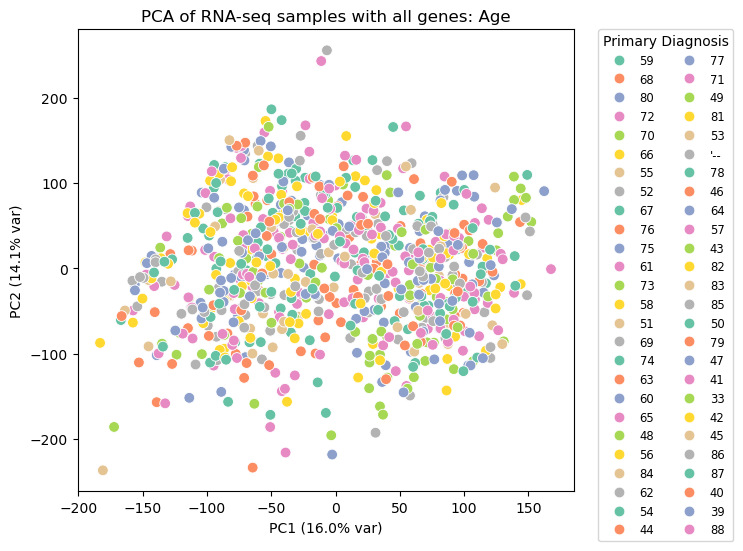

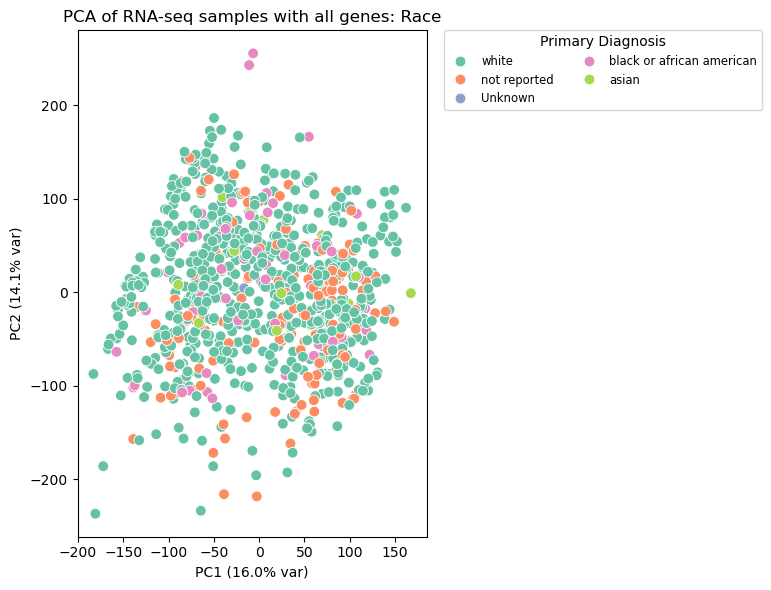

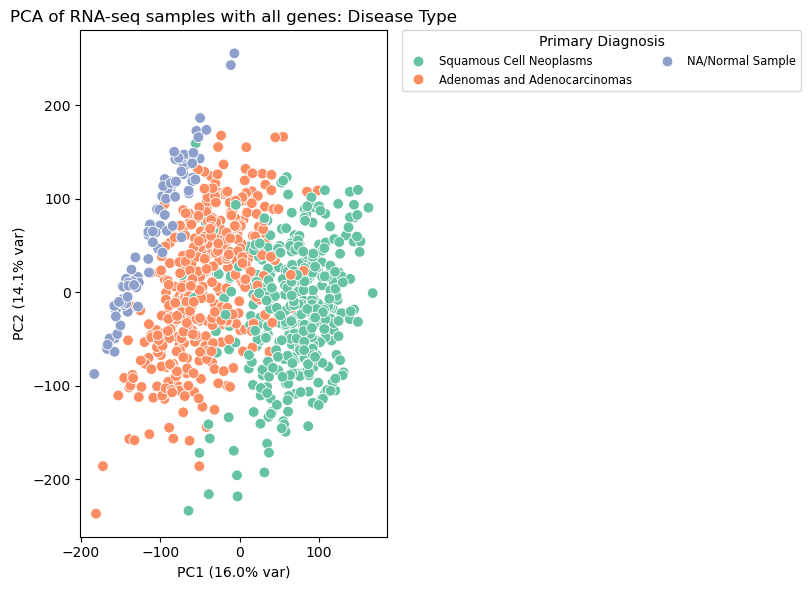

In [84]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples with all genes: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [85]:
X = PCA(n_components=10).fit_transform(log_norm_df)
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: 0.027
Silhouette Score of Labelling Age: -0.286
Silhouette Score of Labelling Race: -0.182
Silhouette Score of Labelling Disease Type: 0.209


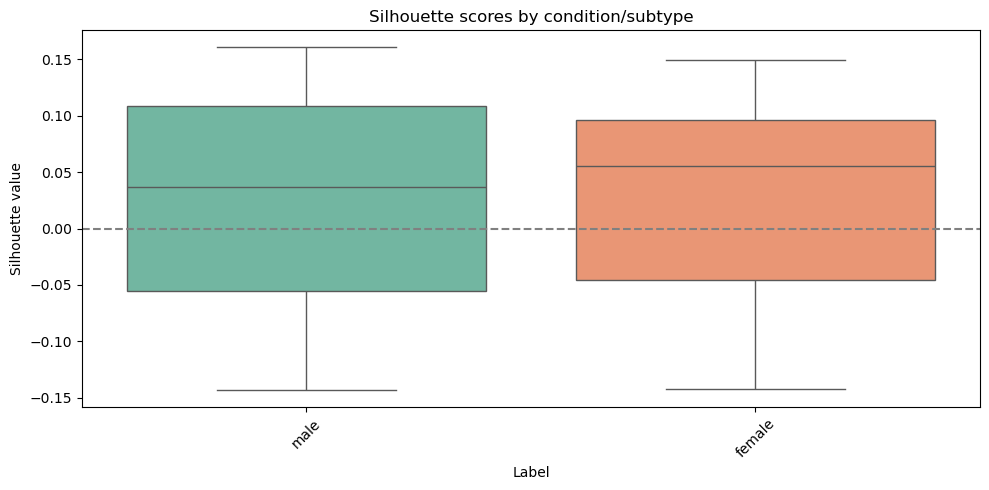

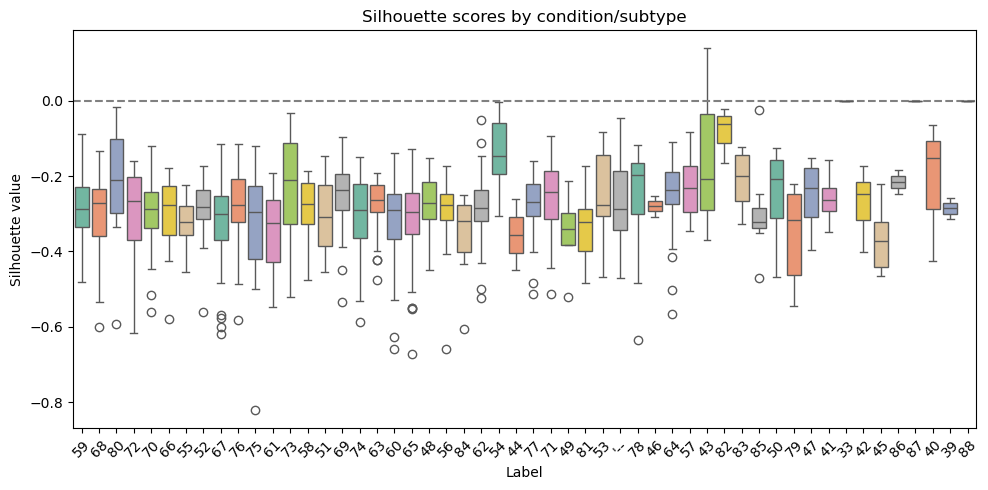

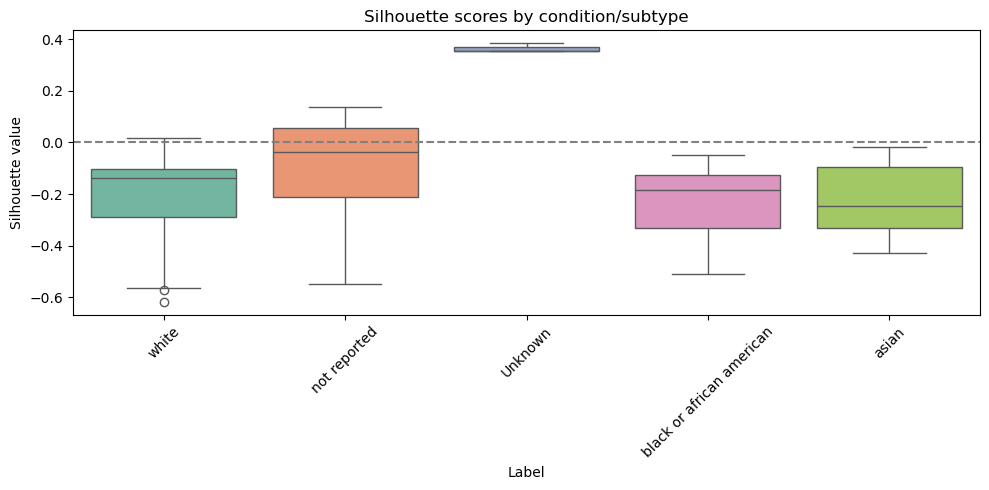

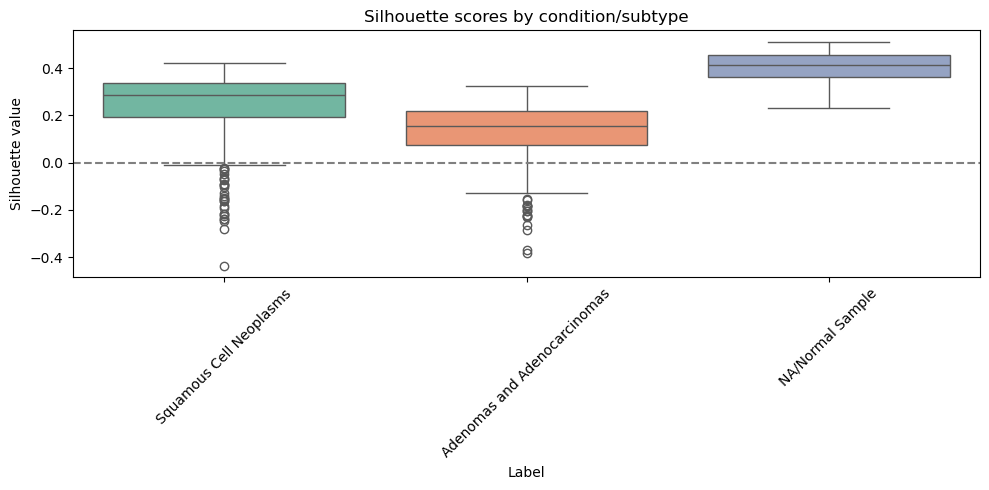

In [86]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## All genes DE from normal samples

In [195]:
with open('Datasets/LungSigGenes/cancer_to_normal_comparison_sig_genes.txt', 'w') as f:
    for item in list(all_cancer_to_normal_sig_genes):
        f.write(f"{item}\n")

In [87]:
df_cancer_to_normal = df.loc[list(all_cancer_to_normal_sig_genes)].copy()

In [88]:
df_for_pca = df_cancer_to_normal.T
log_norm_df = np.log2(df_for_pca + 1)

In [89]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

In [90]:
pca_df

,PC1,PC2,Gender,Age,Race,Disease Type
0,-45.992095,35.615270,male,59,white,Squamous Cell Neoplasms
1,-7.553713,0.548318,male,68,white,Adenomas and Adenocarcinomas
2,98.773027,2.108054,female,80,white,Squamous Cell Neoplasms
3,41.143027,-28.190223,female,72,white,Squamous Cell Neoplasms
4,71.880219,-50.679425,male,70,white,Squamous Cell Neoplasms
...,...,...,...,...,...,...
889,-115.901519,82.218057,female,58,white,NA/Normal Sample
890,-119.179721,-10.592978,female,59,white,NA/Normal Sample
891,-107.808390,182.025053,male,52,black or african american,NA/Normal Sample
892,-129.062077,-30.616159,female,75,white,NA/Normal Sample


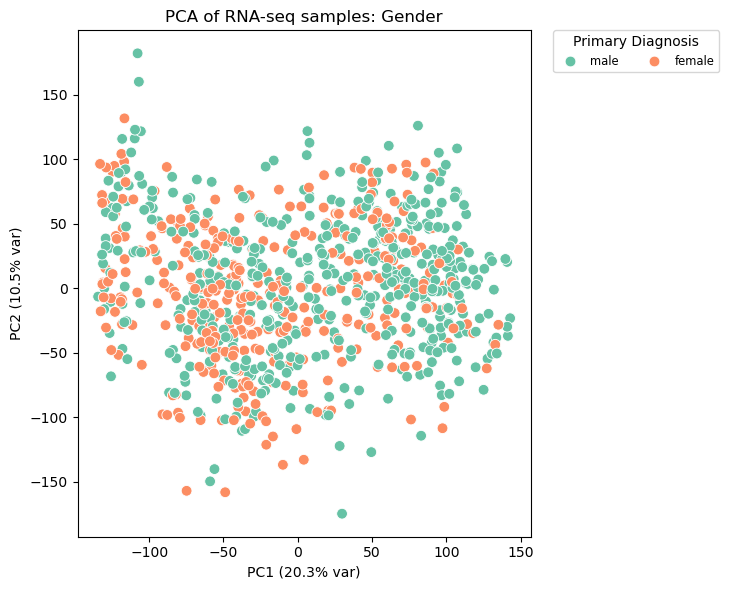

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_47294/761855078.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


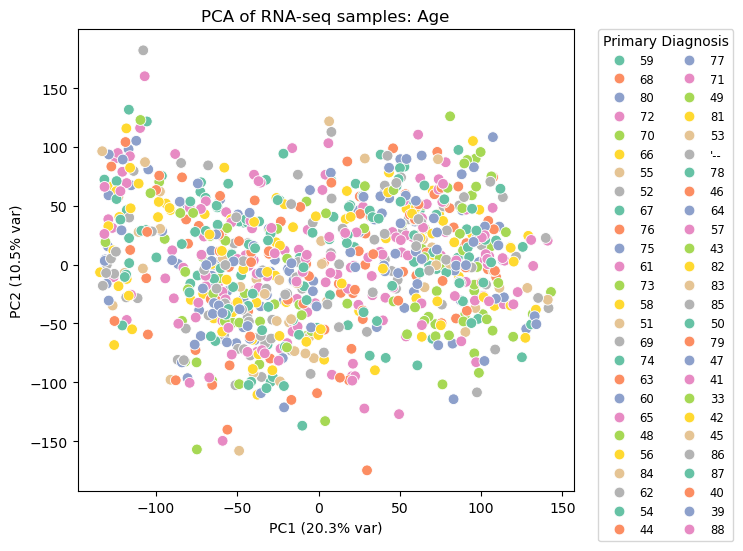

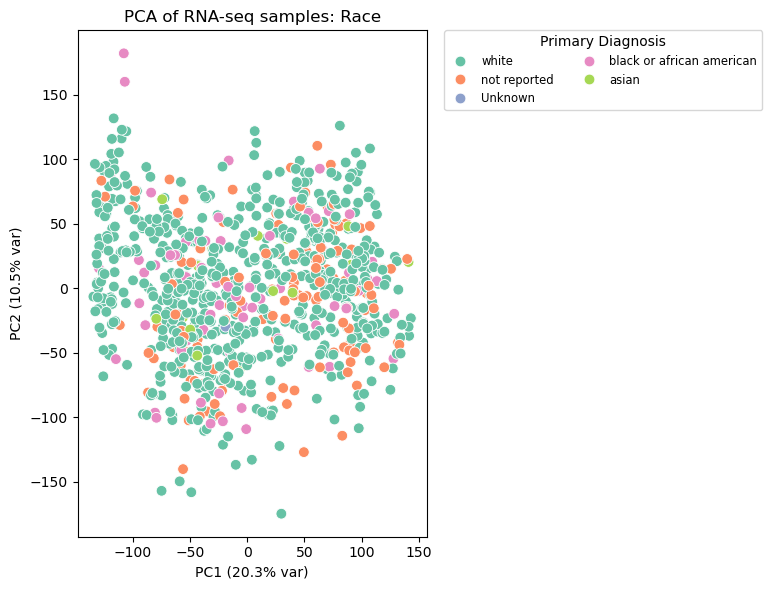

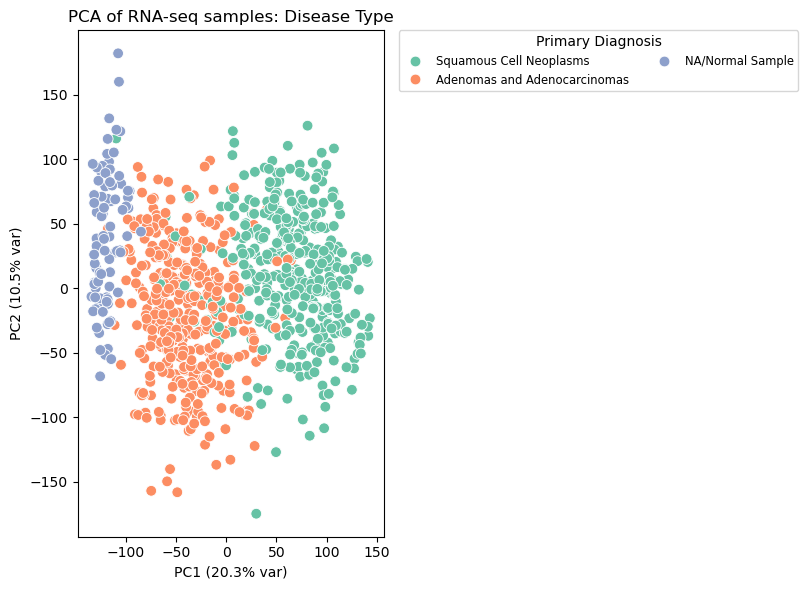

In [91]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [92]:

X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: 0.027
Silhouette Score of Labelling Age: -0.294
Silhouette Score of Labelling Race: -0.186
Silhouette Score of Labelling Disease Type: 0.257


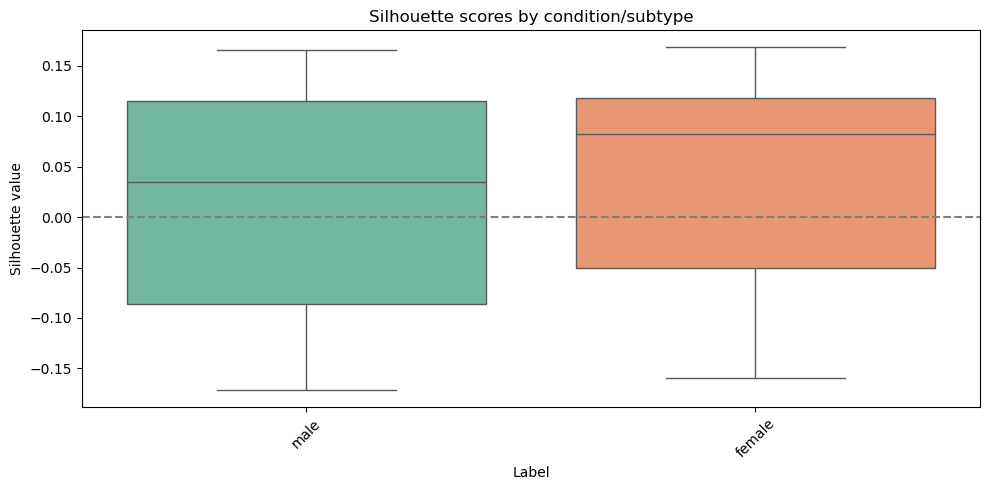

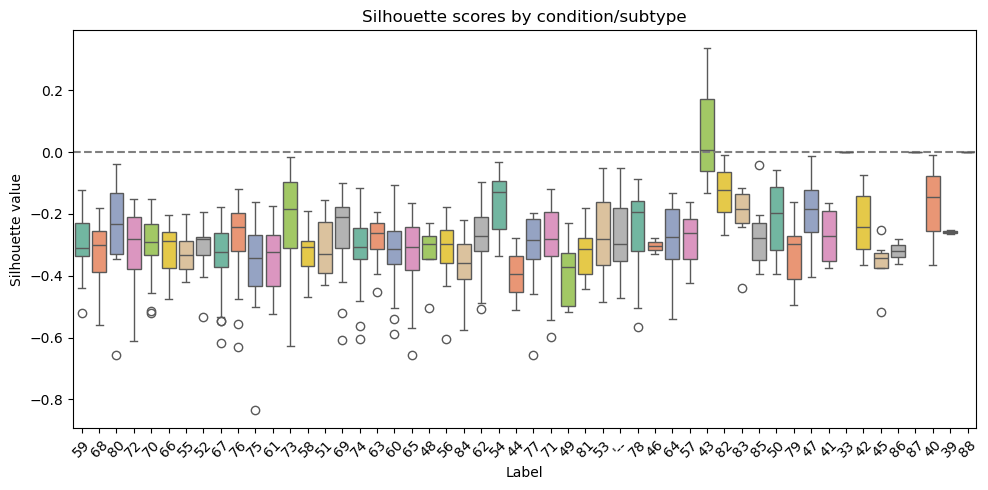

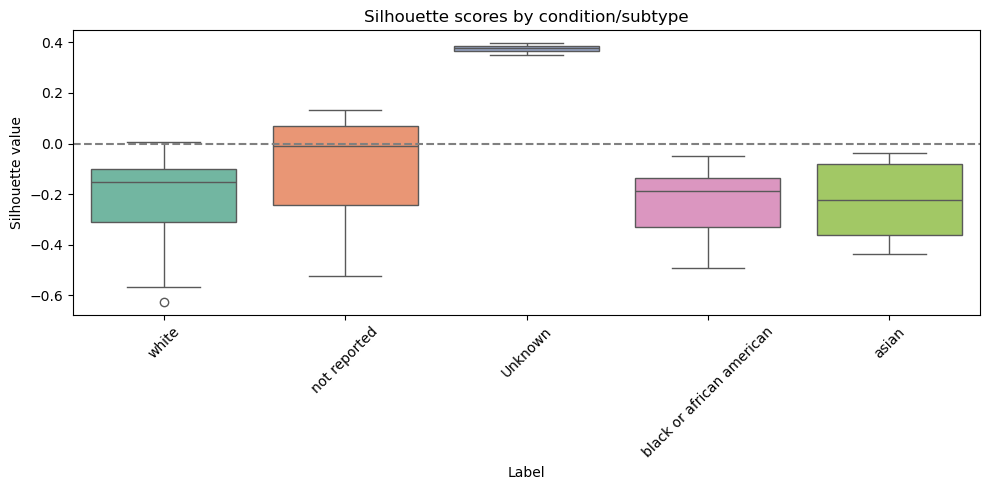

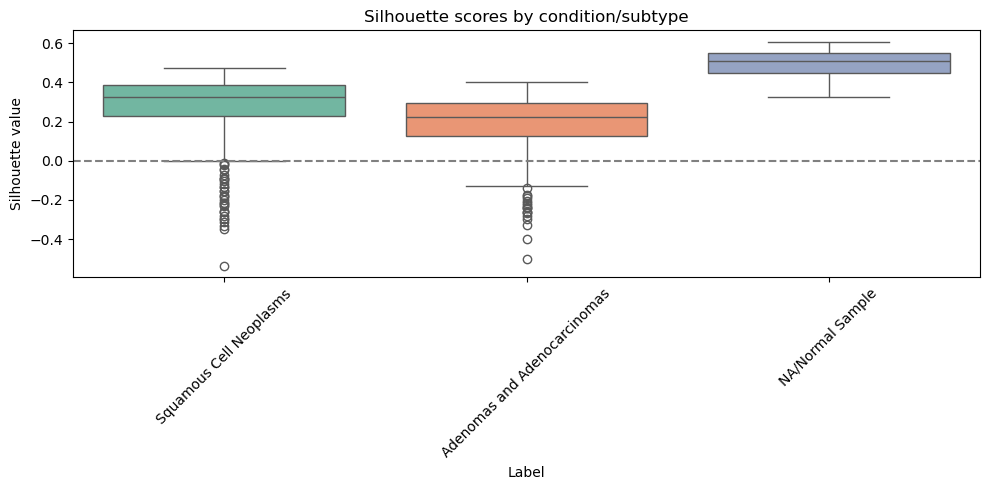

In [93]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## All genes DE cancer to cancer

In [196]:
with open('Datasets/LungSigGenes/cancer_to_cancer_comparison_sig_genes.txt', 'w') as f:
    for item in list(all_cancer_to_cancer_sig_genes):
        f.write(f"{item}\n")

In [94]:
df_cancer_to_cancer = df.loc[list(all_cancer_to_cancer_sig_genes)].copy()

In [95]:
df_for_pca = df_cancer_to_cancer.T
log_norm_df = np.log2(df_for_pca + 1)

In [96]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

In [97]:
pca_df

,PC1,PC2,Gender,Age,Race,Disease Type
0,-32.079618,23.807855,male,59,white,Squamous Cell Neoplasms
1,-16.666556,-21.705253,male,68,white,Adenomas and Adenocarcinomas
2,90.767907,5.111508,female,80,white,Squamous Cell Neoplasms
3,38.268019,-27.469346,female,72,white,Squamous Cell Neoplasms
4,66.759237,-47.872216,male,70,white,Squamous Cell Neoplasms
...,...,...,...,...,...,...
889,-69.334533,66.852197,female,58,white,NA/Normal Sample
890,-74.145273,3.683256,female,59,white,NA/Normal Sample
891,-51.669035,131.457343,male,52,black or african american,NA/Normal Sample
892,-76.376820,-12.115920,female,75,white,NA/Normal Sample


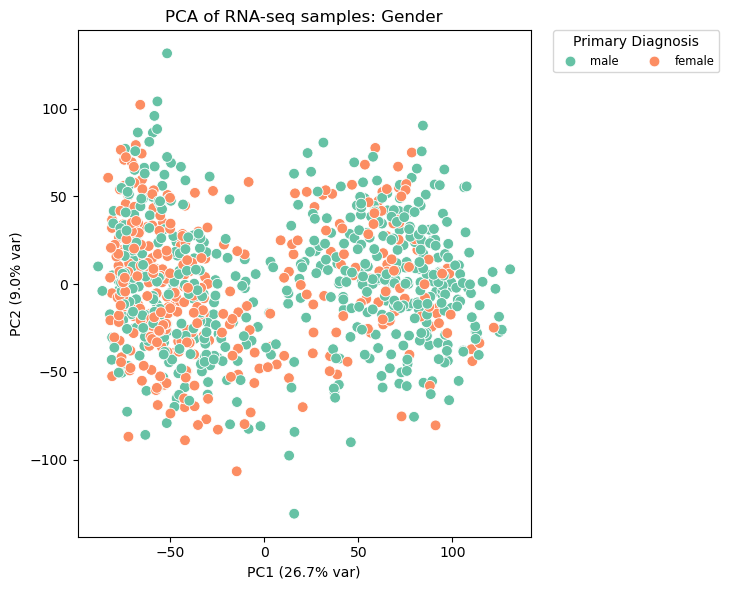

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_47294/761855078.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


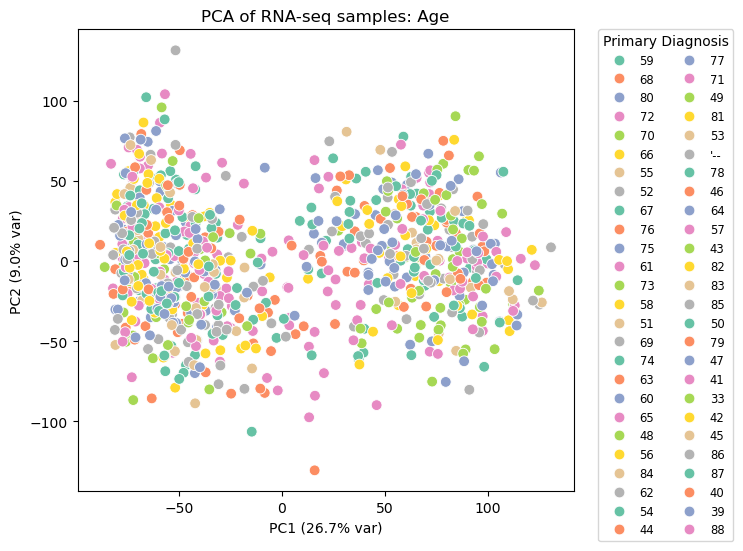

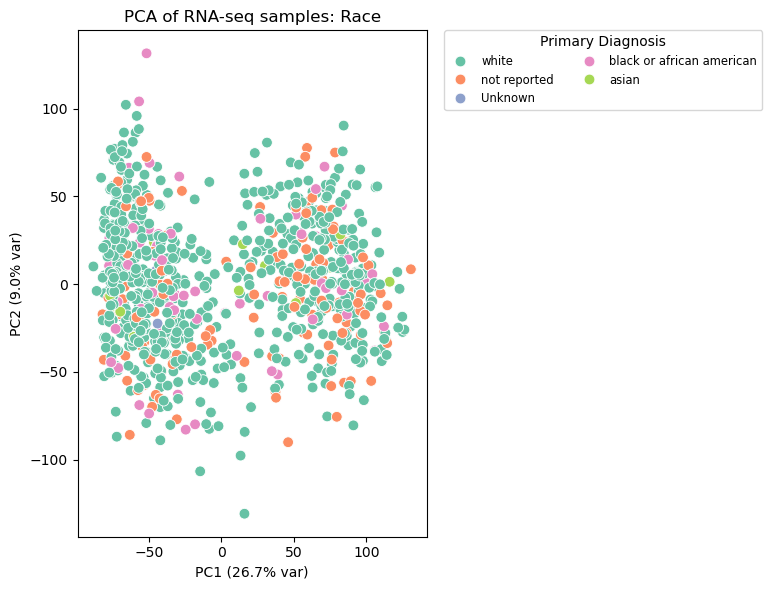

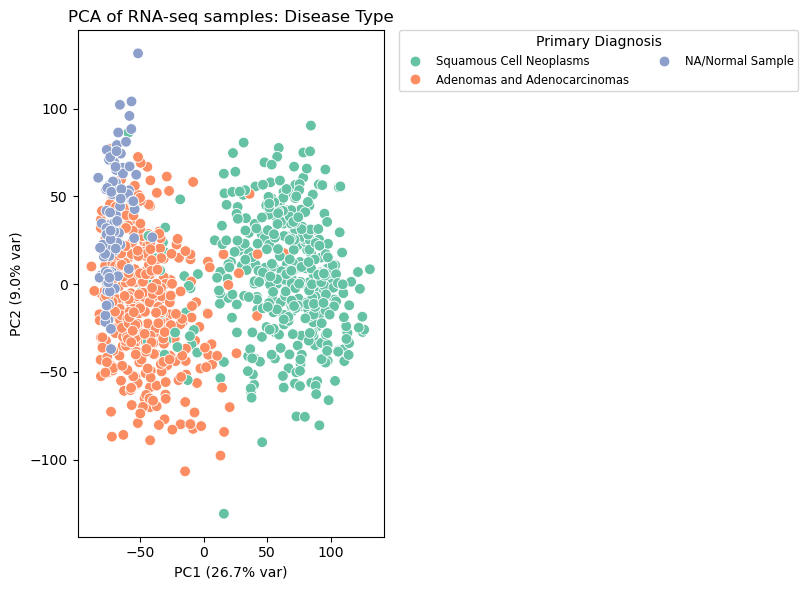

In [98]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [99]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: 0.031
Silhouette Score of Labelling Age: -0.325
Silhouette Score of Labelling Race: -0.206
Silhouette Score of Labelling Disease Type: 0.276


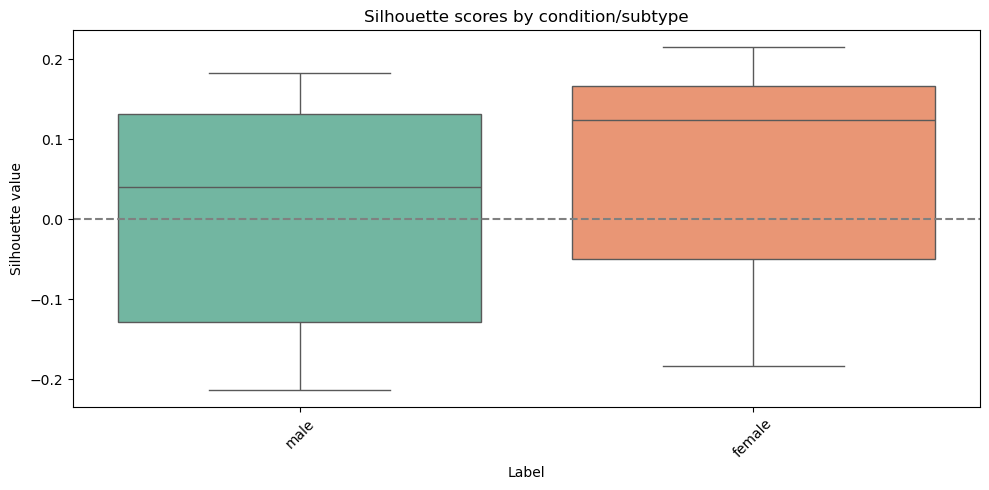

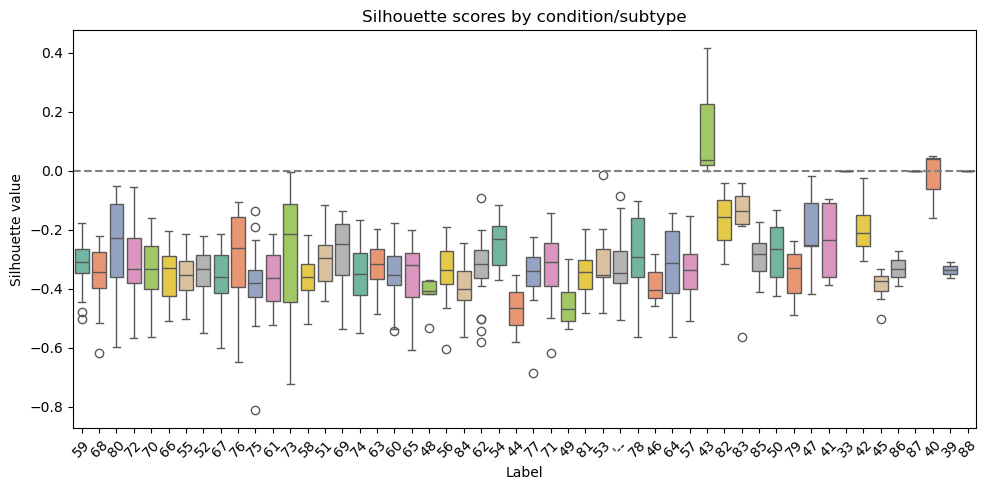

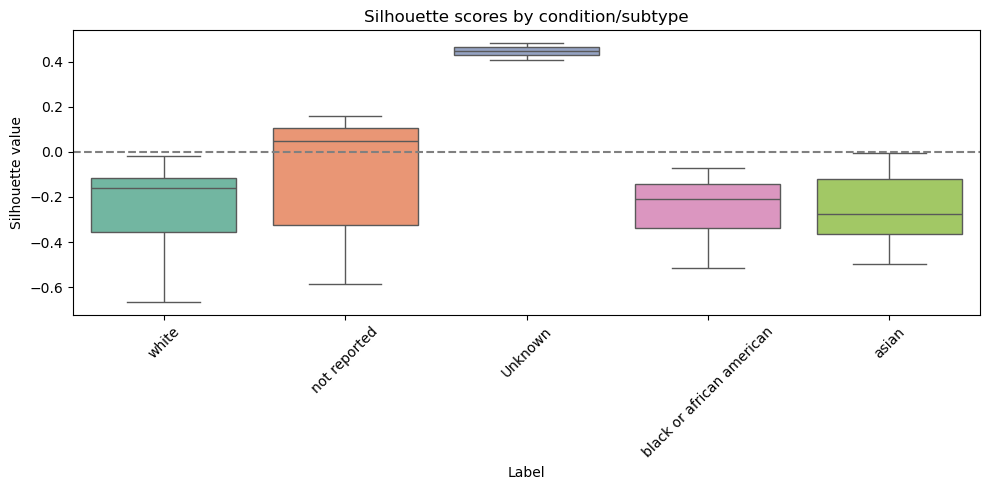

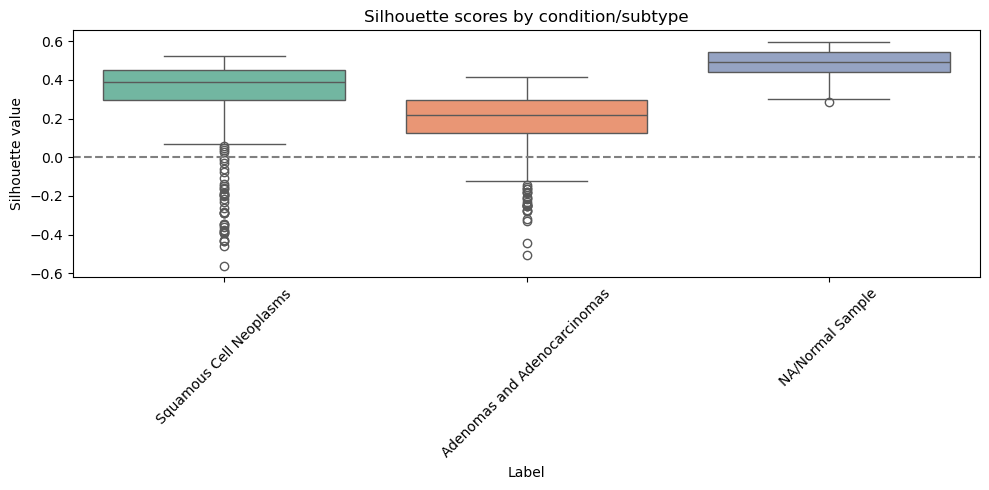

In [100]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## Intersection gene set

In [278]:
with open('Datasets/LungSigGenes/intersection_sig_genes.txt', 'w') as f:
    for item in list(intersection_sig_genes):
        f.write(f"{item}\n")

In [283]:
df_intersection = df.loc[list(intersection_sig_genes)].copy()


In [284]:
df_for_pca = df_intersection.T
log_norm_df = np.log2(df_for_pca + 1)

In [285]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

# Put result in a DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

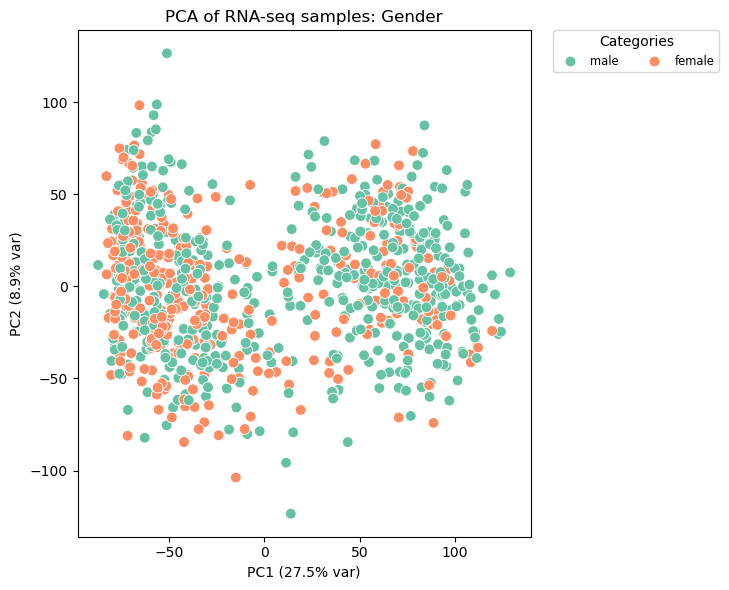

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_47294/4178465455.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


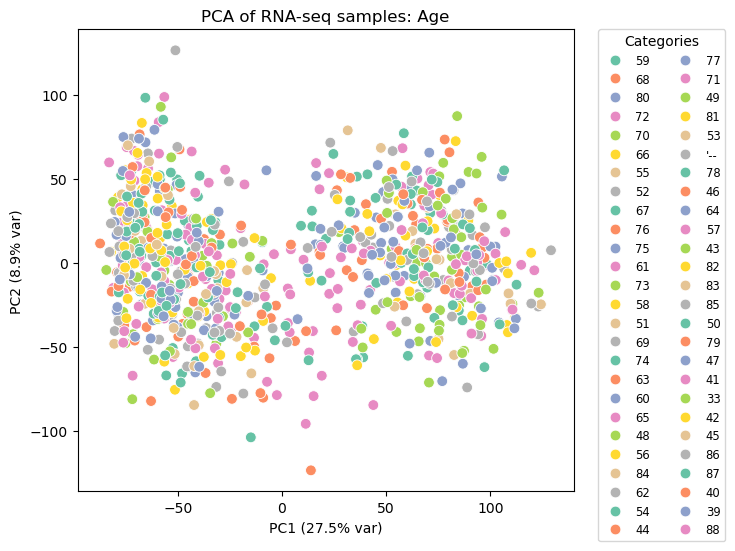

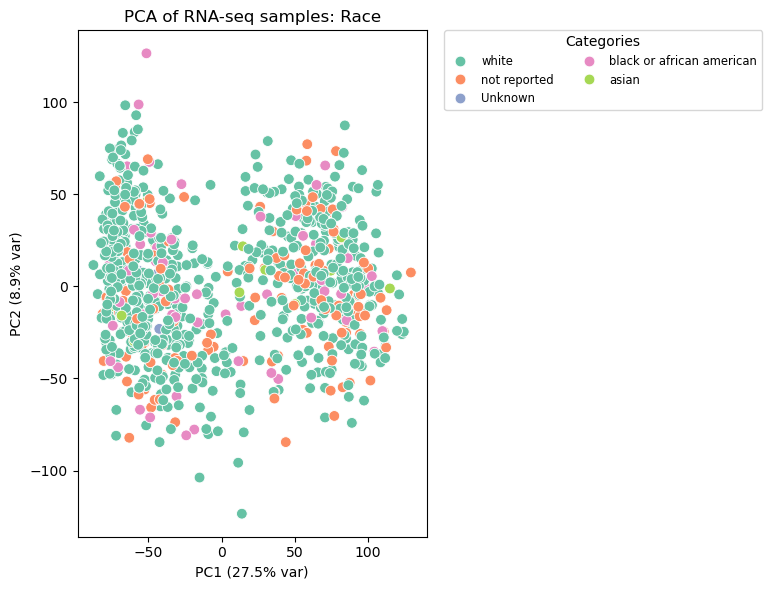

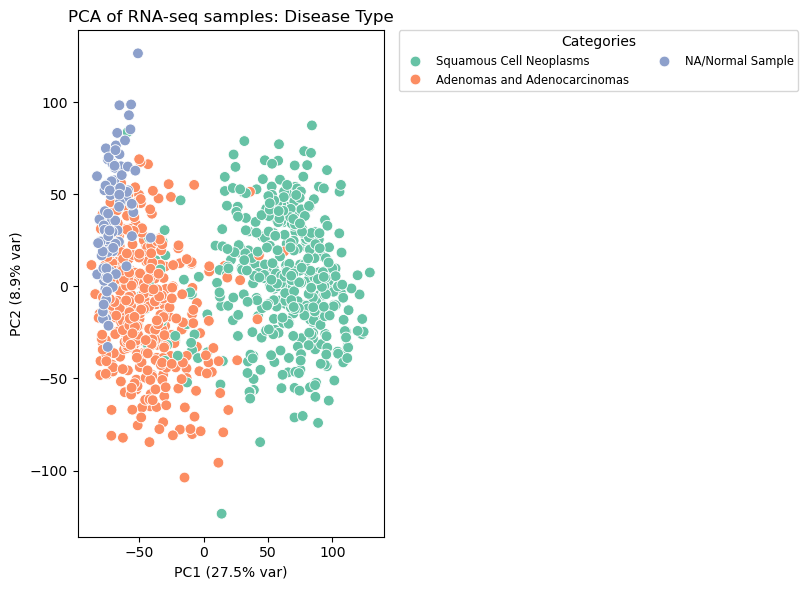

In [286]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [105]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: 0.031
Silhouette Score of Labelling Age: -0.329
Silhouette Score of Labelling Race: -0.208
Silhouette Score of Labelling Disease Type: 0.280


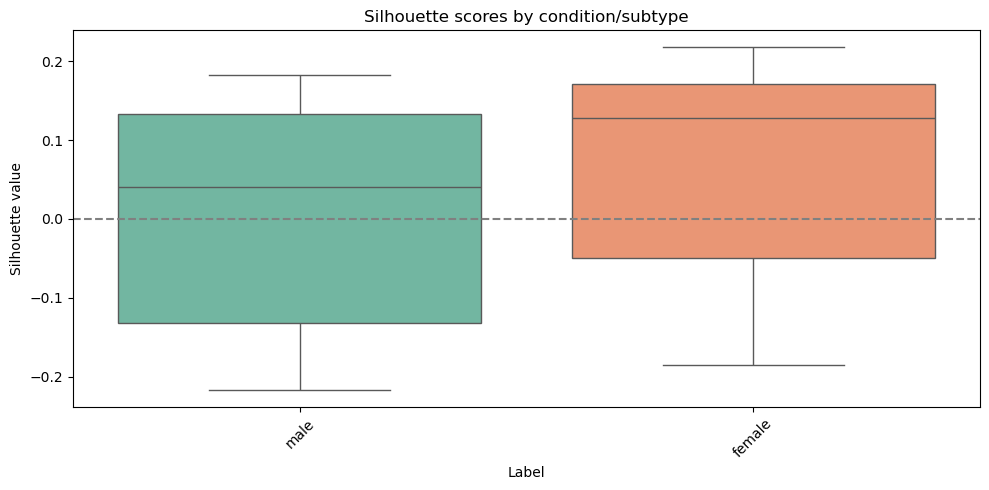

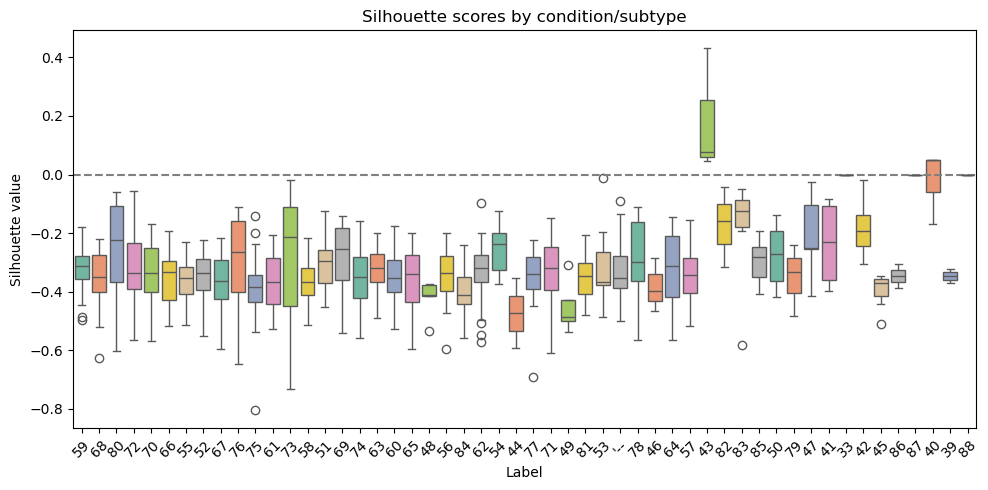

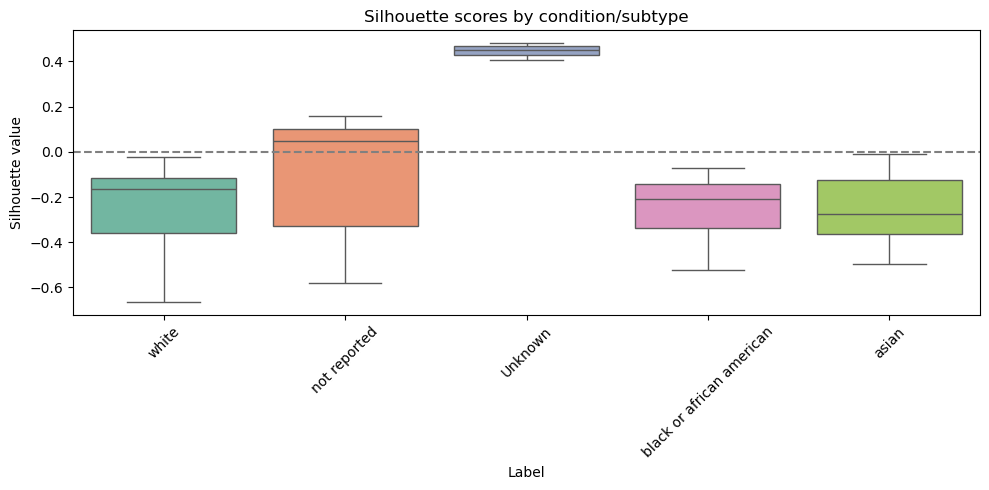

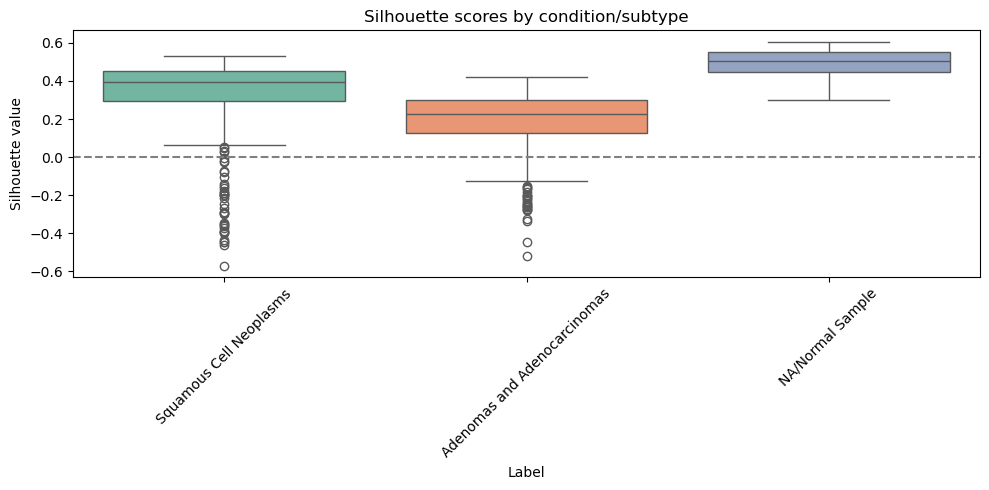

In [106]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## Union Gene set

In [198]:
with open('Datasets/LungSigGenes/union_sig_genes.txt', 'w') as f:
    for item in list(union_sig_genes):
        f.write(f"{item}\n")

In [107]:
df_union = df.loc[list(union_sig_genes)].copy()

In [108]:
df_for_pca = df_union.T
log_norm_df = np.log2(df_for_pca + 1)

In [109]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

# Put result in a DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

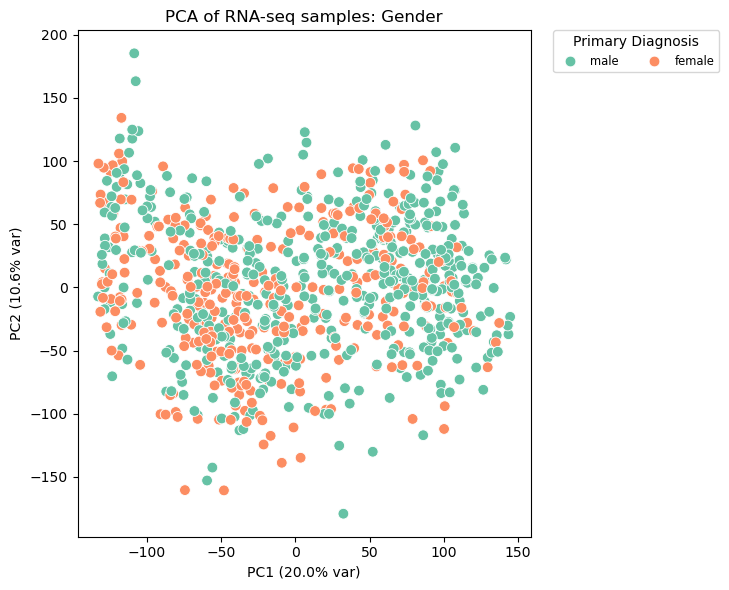

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_47294/761855078.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


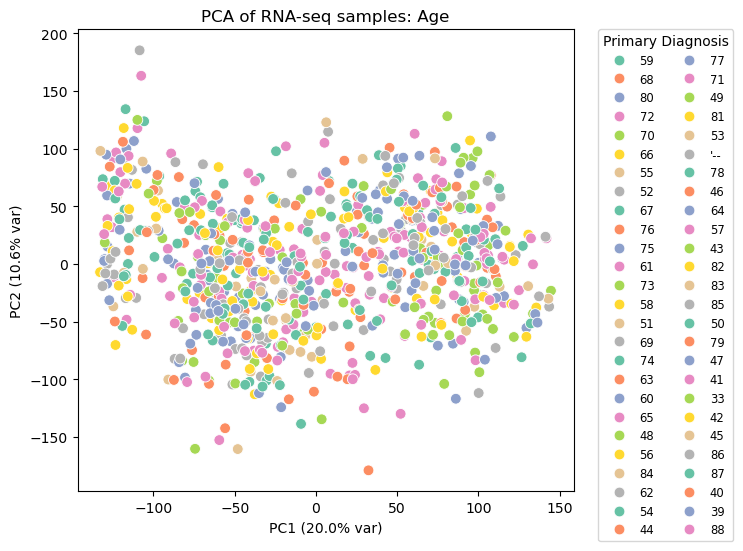

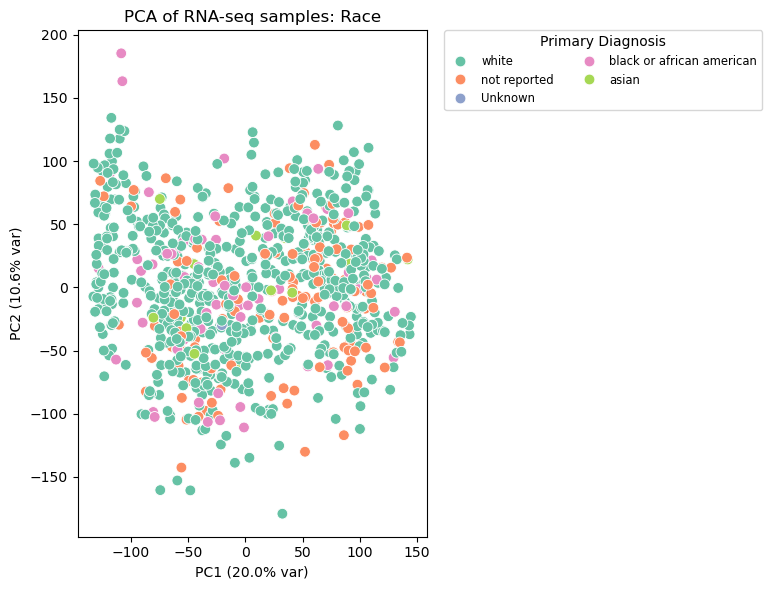

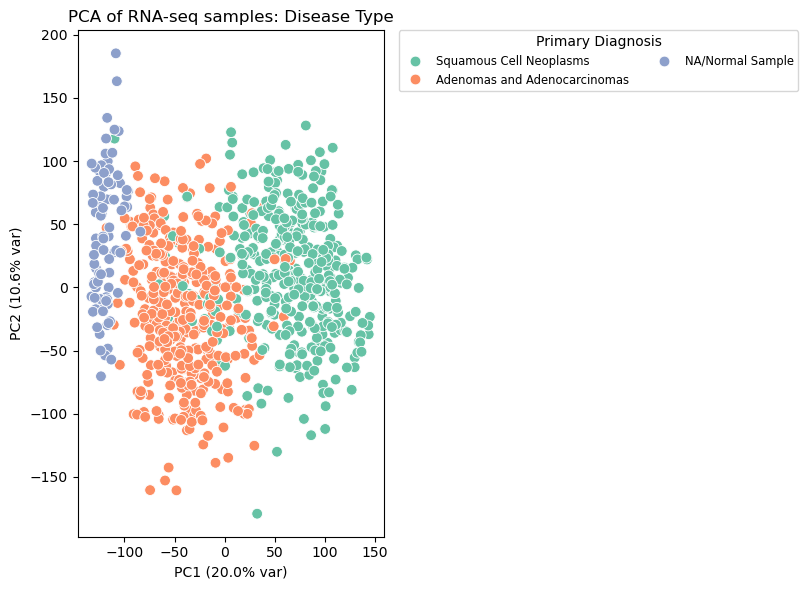

In [110]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [111]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: 0.027
Silhouette Score of Labelling Age: -0.293
Silhouette Score of Labelling Race: -0.185
Silhouette Score of Labelling Disease Type: 0.256


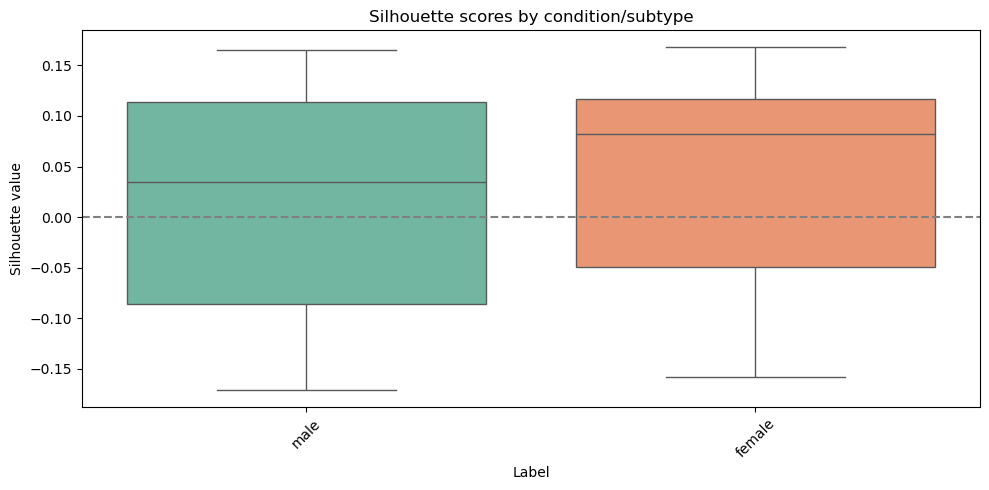

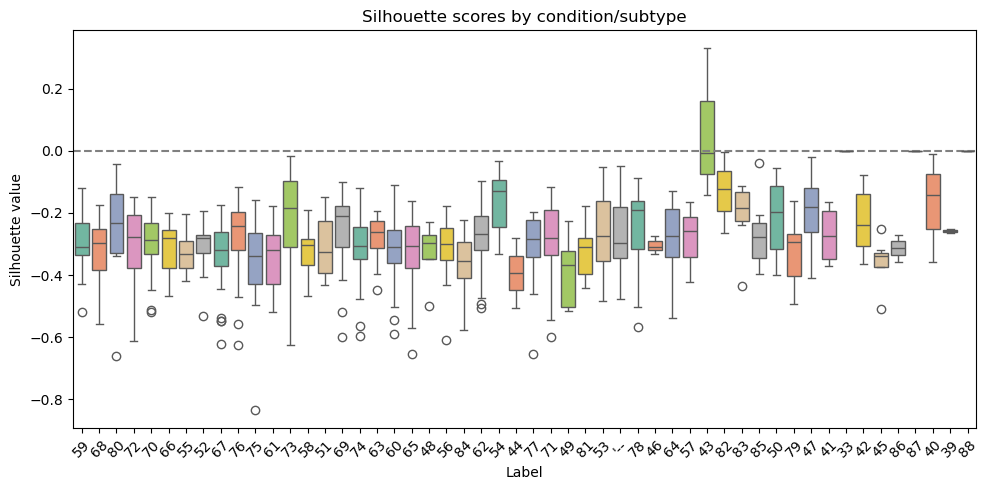

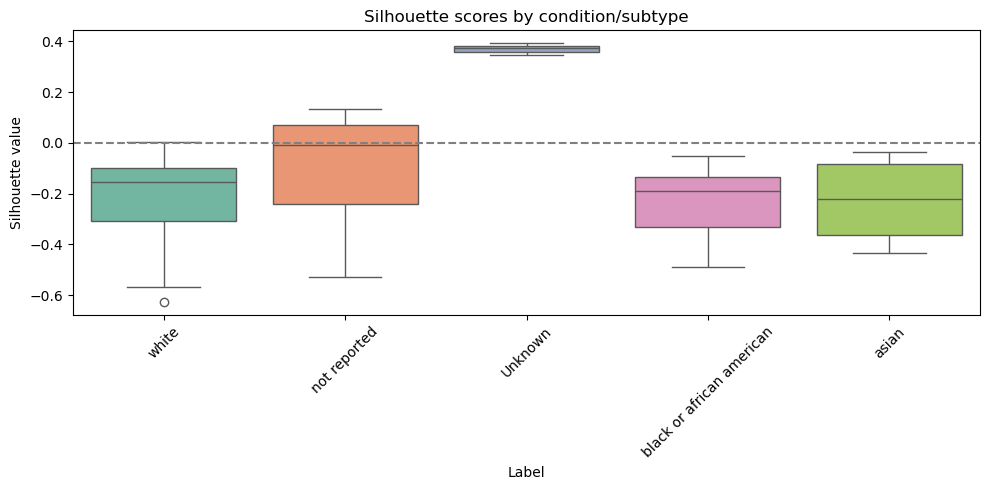

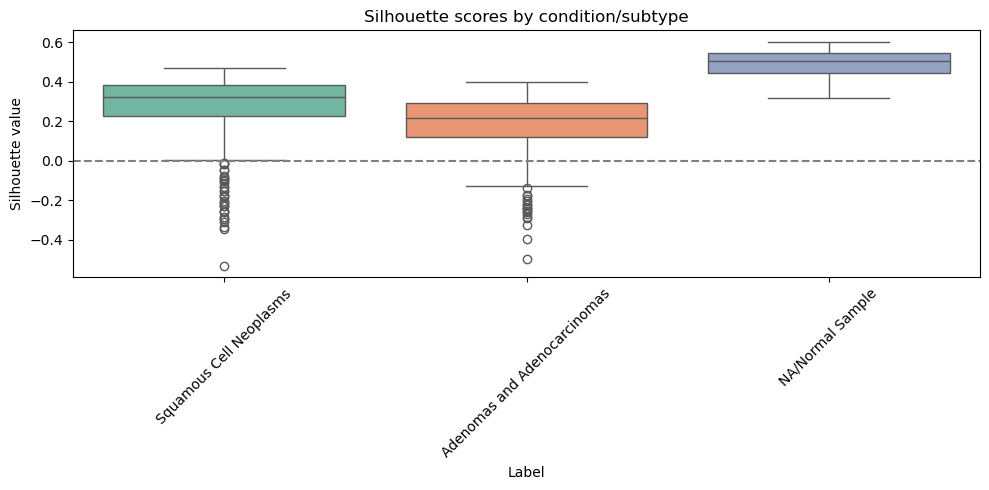

In [112]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

## Comparison with random

In [183]:
all_genes = list(df.index)

In [184]:
num_rand_genes = len(all_cancer_to_cancer_sig_genes)

In [185]:
num_rand_genes

3518

In [186]:
rand_genes = set()
while len(rand_genes) < num_rand_genes:
    random_idx = random.randint(0, len(all_genes)-1)
    rand_genes.add(all_genes[random_idx])
len(rand_genes)

3518

In [187]:
df_rand = df.loc[list(rand_genes)].copy()

In [188]:
df_for_pca = df_rand.T
log_norm_df = np.log2(df_for_pca + 1)

In [189]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(log_norm_df)

# Put result in a DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
for key in columns_to_group_dict:
    pca_df[key] = list(sample_clinical[columns_to_group_dict[key]])

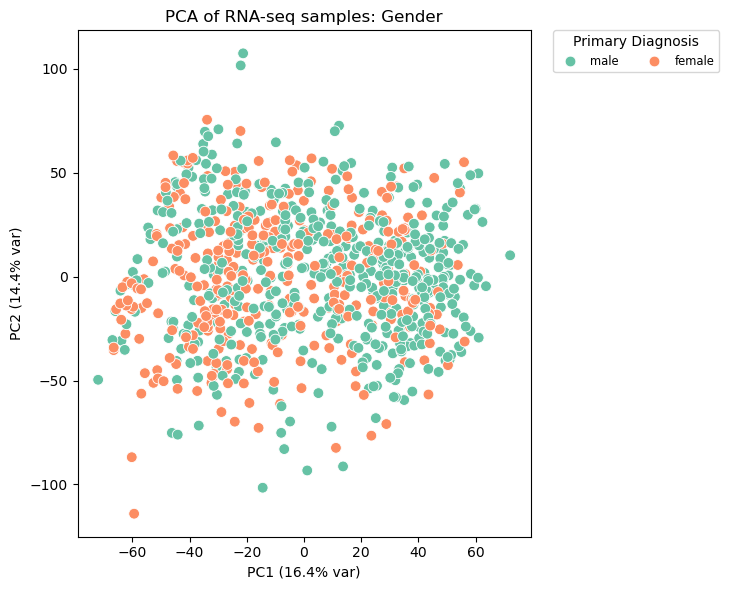

/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_47294/761855078.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


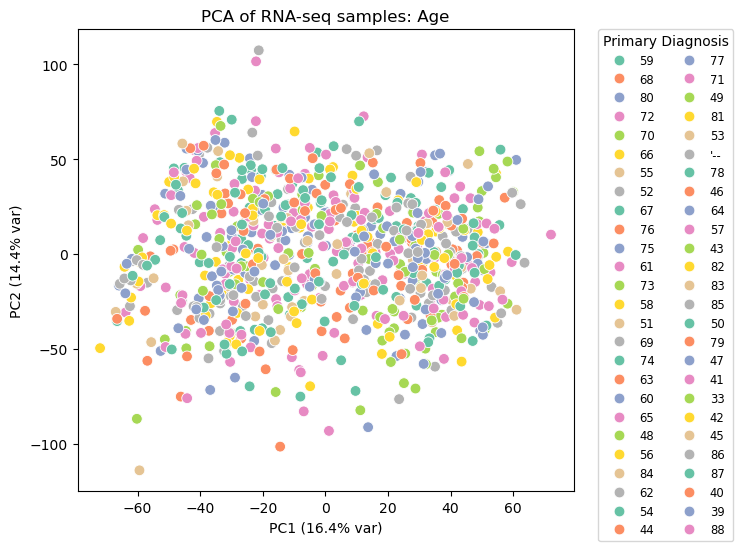

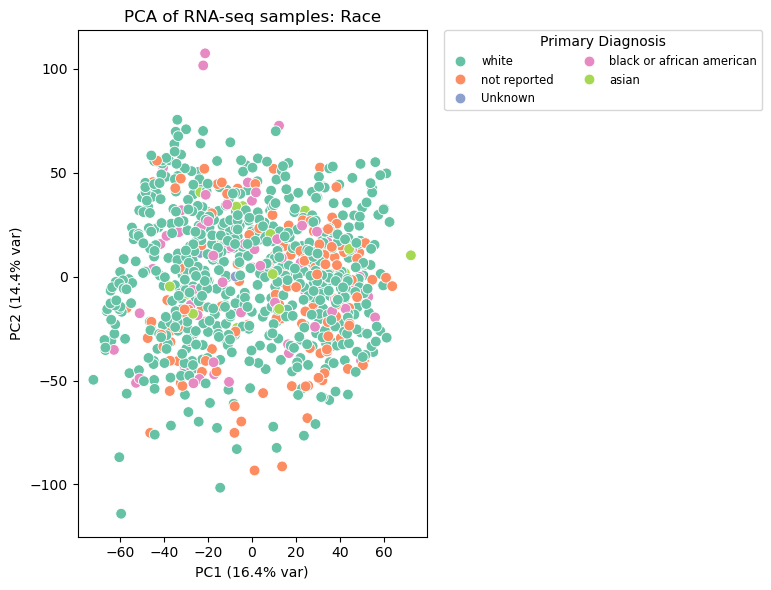

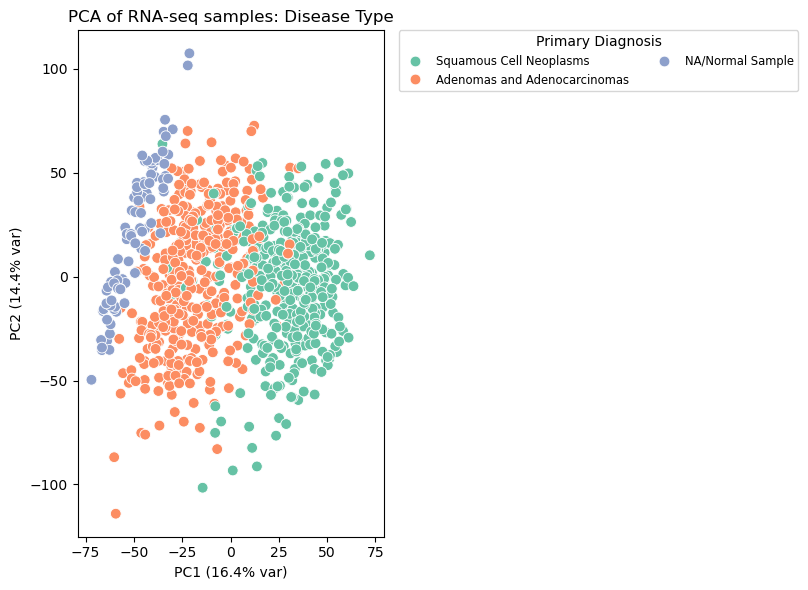

In [190]:
for key in columns_to_group_dict:
    save_pca_plot(pca_df, pca.explained_variance_ratio_, key,f"PCA of RNA-seq samples: {key}", f"pca_{columns_to_group_dict[key].replace(' ', '_')}.png", save = True)

In [191]:
X = PCA(n_components=10).fit_transform(log_norm_df)
#labels = sample_conditions 
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]]
    score = silhouette_score(X, labels)
    print(f"Silhouette Score of Labelling {key}: {score:.3f}")

Silhouette Score of Labelling Gender: 0.027
Silhouette Score of Labelling Age: -0.283
Silhouette Score of Labelling Race: -0.176
Silhouette Score of Labelling Disease Type: 0.208


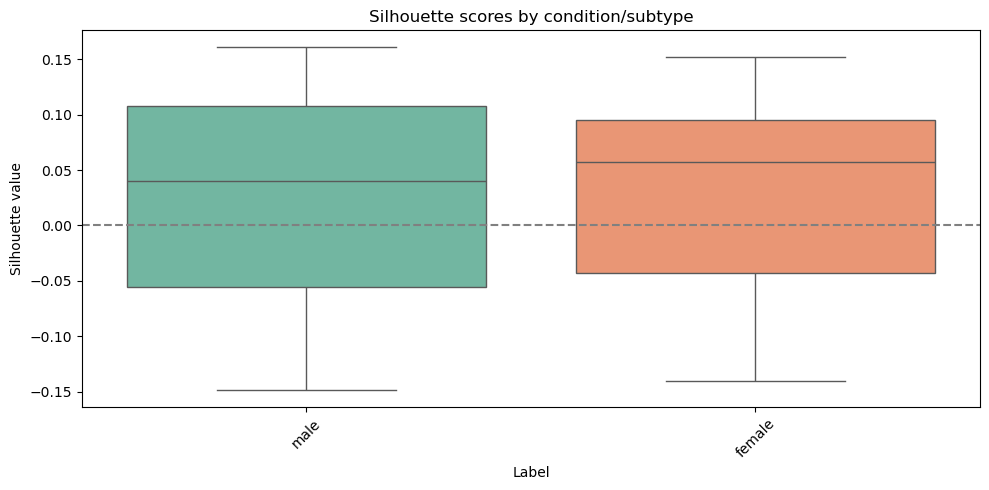

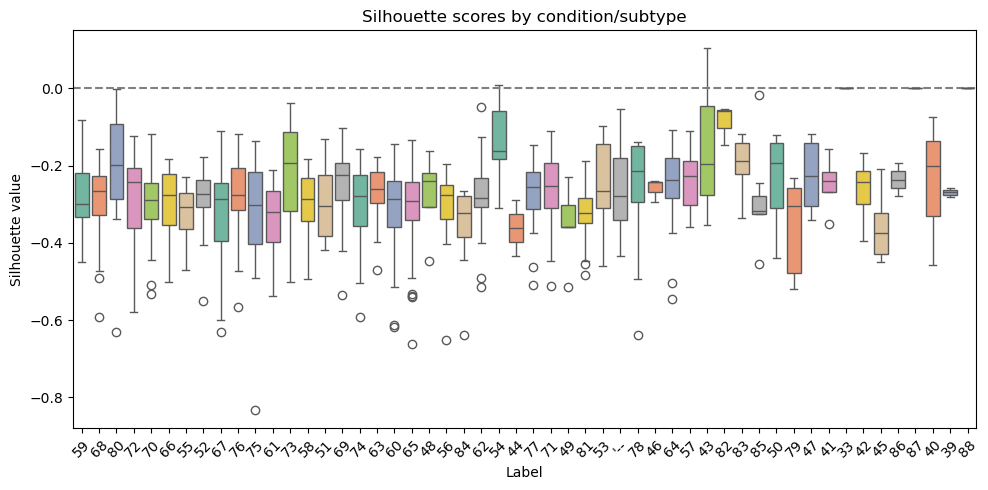

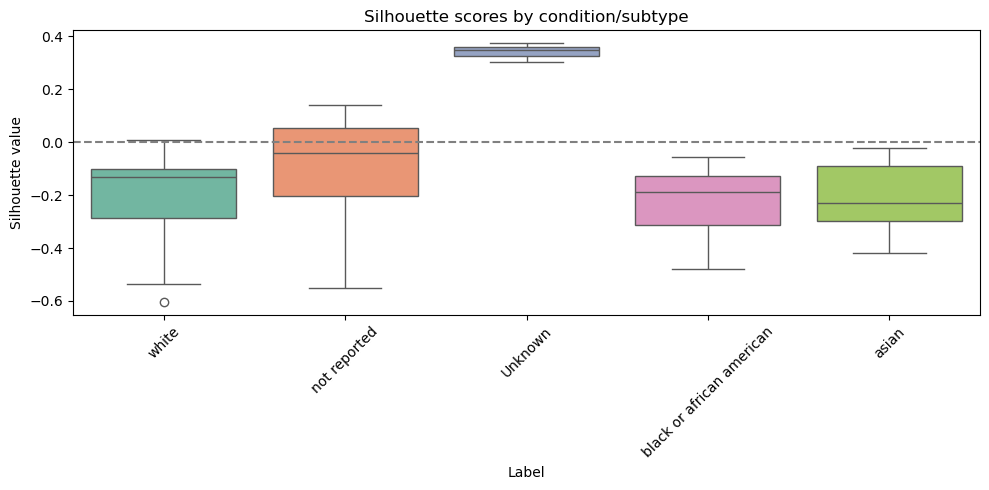

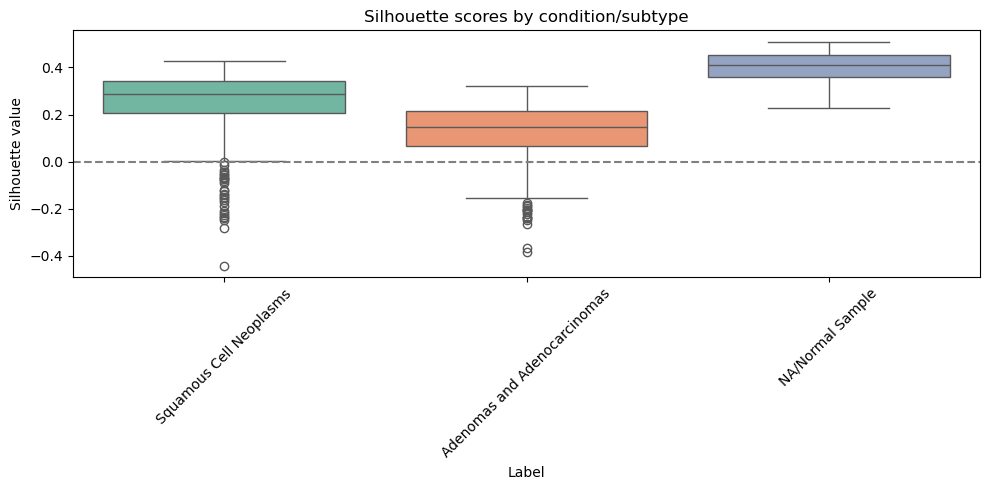

In [192]:
for key in columns_to_group_dict:
    labels = sample_clinical[columns_to_group_dict[key]] 
    sil_values = silhouette_samples(X, labels)
    sil_df = pd.DataFrame({
    'silhouette': sil_values,
    'label': labels.values
    })
    plot_silhouette(sil_df)

In [194]:
sample_clinical

,Case ID,cases.submitter_id,demographic.gender,demographic.age_at_index,demographic.race,cases.disease_type,diagnoses.ajcc_pathologic_stage,diagnoses.classification_of_tumor,diagnoses.primary_diagnosis
Unnamed: 0,,,,,,,,,
5faf8a12-a2aa-44f1-b099-02106766ec94,TCGA-NC-A5HJ,TCGA-NC-A5HJ,male,59,white,Squamous Cell Neoplasms,Stage IIB,primary,"Squamous cell carcinoma, NOS"
6855a406-c085-45c7-b789-981786f0c775,TCGA-38-4629,TCGA-38-4629,male,68,white,Adenomas and Adenocarcinomas,Stage IIB,primary,"Adenocarcinoma, NOS"
e2445ad6-2a6a-4ec3-84d8-93cc3c180a58,TCGA-22-1012,TCGA-22-1012,female,80,white,Squamous Cell Neoplasms,Stage IB,primary,"Squamous cell carcinoma, NOS"
4b167e70-e4e6-47f7-9fe9-11cf20f0d442,TCGA-39-5035,TCGA-39-5035,female,72,white,Squamous Cell Neoplasms,Stage IA,primary,"Squamous cell carcinoma, NOS"
470afda8-c4a4-4161-b6e7-1f0d2372d2c7,TCGA-85-8481,TCGA-85-8481,male,70,white,Squamous Cell Neoplasms,Stage IIB,primary,"Squamous cell carcinoma, NOS"
...,...,...,...,...,...,...,...,...,...
6c20a899-c806-46d0-b744-a26e53a9cb45,TCGA-55-6985,TCGA-55-6985,female,58,white,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample
c36f84e5-8c59-46fe-af32-7f70684383b2,TCGA-55-6971,TCGA-55-6971,female,59,white,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample
4c994cf9-52d0-4c05-97c0-fd2d3ffb9100,TCGA-43-3394,TCGA-43-3394,male,52,black or african american,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample,NA/Normal Sample


In [249]:
gene_name_df = pd.read_csv("lung_gene_names.tsv", sep="\t", skiprows=1)

In [250]:
gene_name_df

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,6004315,6004315,6004315,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,38166836,38166836,38166836,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,16553967,78083558,17008693,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,16068400,89734,13953007,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,1821,0,1821,10.3371,11.3818,10.7364
...,...,...,...,...,...,...,...,...,...
60659,ENSG00000288669.1,AC008763.4,protein_coding,0,0,0,0.0000,0.0000,0.0000
60660,ENSG00000288670.1,AL592295.6,lncRNA,114,0,121,1.6245,1.7886,1.6872
60661,ENSG00000288671.1,AC006486.3,protein_coding,0,0,0,0.0000,0.0000,0.0000
60662,ENSG00000288674.1,AL391628.1,protein_coding,13,3,10,0.0348,0.0383,0.0361


## Gene Id to Gene Name Conversion For GO

In [251]:
gene_ids = list(df.index)

In [252]:
valid_ids = [gid for gid in gene_ids if gid in gene_name_df.index]
gene_id_to_name = gene_name_df.loc[valid_ids, 'gene_name'].to_dict()

In [253]:
gene_ids

['ENSG00000000003.15',
 'ENSG00000000005.6',
 'ENSG00000000419.13',
 'ENSG00000000457.14',
 'ENSG00000000460.17',
 'ENSG00000000938.13',
 'ENSG00000000971.16',
 'ENSG00000001036.14',
 'ENSG00000001084.13',
 'ENSG00000001167.14',
 'ENSG00000001460.18',
 'ENSG00000001461.17',
 'ENSG00000001497.18',
 'ENSG00000001561.7',
 'ENSG00000001617.12',
 'ENSG00000001626.16',
 'ENSG00000001629.10',
 'ENSG00000001630.17',
 'ENSG00000001631.16',
 'ENSG00000002016.18',
 'ENSG00000002330.14',
 'ENSG00000002549.12',
 'ENSG00000002586.20',
 'ENSG00000002587.10',
 'ENSG00000002726.21',
 'ENSG00000002745.13',
 'ENSG00000002746.15',
 'ENSG00000002822.15',
 'ENSG00000002834.18',
 'ENSG00000002919.15',
 'ENSG00000002933.9',
 'ENSG00000003056.8',
 'ENSG00000003096.14',
 'ENSG00000003137.8',
 'ENSG00000003147.19',
 'ENSG00000003249.15',
 'ENSG00000003393.15',
 'ENSG00000003400.15',
 'ENSG00000003402.20',
 'ENSG00000003436.16',
 'ENSG00000003509.16',
 'ENSG00000003756.17',
 'ENSG00000003987.14',
 'ENSG0000000398

In [254]:
gene_name_df

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
0,N_unmapped,NaN,NaN,6004315,6004315,6004315,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,38166836,38166836,38166836,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,16553967,78083558,17008693,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,16068400,89734,13953007,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,1821,0,1821,10.3371,11.3818,10.7364
...,...,...,...,...,...,...,...,...,...
60659,ENSG00000288669.1,AC008763.4,protein_coding,0,0,0,0.0000,0.0000,0.0000
60660,ENSG00000288670.1,AL592295.6,lncRNA,114,0,121,1.6245,1.7886,1.6872
60661,ENSG00000288671.1,AC006486.3,protein_coding,0,0,0,0.0000,0.0000,0.0000
60662,ENSG00000288674.1,AL391628.1,protein_coding,13,3,10,0.0348,0.0383,0.0361


In [255]:
gene_id_to_name

{}

In [233]:
gene_name_df

,,,,,,,,# gene-model: GENCODE v36
gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
N_unmapped,NaN,NaN,1961927,1961927,1961927,NaN,NaN,NaN
N_multimapping,NaN,NaN,4523899,4523899,4523899,NaN,NaN,NaN
N_noFeature,NaN,NaN,1806860,28155361,28076108,NaN,NaN,NaN
N_ambiguous,NaN,NaN,5809843,1435356,1439403,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
ENSG00000288669.1,AC008763.4,protein_coding,1,1,0,0.0164,0.0052,0.0058
ENSG00000288670.1,AL592295.6,lncRNA,109,54,57,3.9363,1.2500,1.3989
ENSG00000288671.1,AC006486.3,protein_coding,0,0,0,0.0000,0.0000,0.0000
ENSG00000288674.1,AL391628.1,protein_coding,9,7,2,0.0611,0.0194,0.0217


In [256]:
import mygene

mg = mygene.MyGeneInfo()
# Remove version numbers if needed
gene_ids = [gid.split('.')[0] for gid in gene_ids]

# Query mygene.info
results = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol', species='human')

# Build dictionary
id_to_name = {entry['query']: entry.get('symbol', None) for entry in results}


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
1 input query terms found dup hits:	[('ENSG00000215156', 2)]
2 input query terms found no hit:	['ENSG00000168078', 'ENSG00000189144']


In [257]:
id_to_name

{'ENSG00000000003': 'TSPAN6',
 'ENSG00000000005': 'TNMD',
 'ENSG00000000419': 'DPM1',
 'ENSG00000000457': 'SCYL3',
 'ENSG00000000460': 'FIRRM',
 'ENSG00000000938': 'FGR',
 'ENSG00000000971': 'CFH',
 'ENSG00000001036': 'FUCA2',
 'ENSG00000001084': 'GCLC',
 'ENSG00000001167': 'NFYA',
 'ENSG00000001460': 'STPG1',
 'ENSG00000001461': 'NIPAL3',
 'ENSG00000001497': 'LAS1L',
 'ENSG00000001561': 'ENPP4',
 'ENSG00000001617': 'SEMA3F',
 'ENSG00000001626': 'CFTR',
 'ENSG00000001629': 'ANKIB1',
 'ENSG00000001630': 'CYP51A1',
 'ENSG00000001631': 'KRIT1',
 'ENSG00000002016': 'RAD52',
 'ENSG00000002330': 'BAD',
 'ENSG00000002549': 'LAP3',
 'ENSG00000002586': 'CD99',
 'ENSG00000002587': 'HS3ST1',
 'ENSG00000002726': 'AOC1',
 'ENSG00000002745': 'WNT16',
 'ENSG00000002746': 'HECW1',
 'ENSG00000002822': 'MAD1L1',
 'ENSG00000002834': 'LASP1',
 'ENSG00000002919': 'SNX11',
 'ENSG00000002933': 'TMEM176A',
 'ENSG00000003056': 'M6PR',
 'ENSG00000003096': 'KLHL13',
 'ENSG00000003137': 'CYP26B1',
 'ENSG000000031

In [258]:
sig_gene_ids = list(df_intersection.index)

In [259]:
mg = mygene.MyGeneInfo()
# Remove version numbers if needed
sig_gene_ids = [gid.split('.')[0] for gid in sig_gene_ids]

# Query mygene.info
results = mg.querymany(sig_gene_ids, scopes='ensembl.gene', fields='symbol', species='human')

# Build dictionary
id_to_name = {entry['query']: entry.get('symbol', None) for entry in results}


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [263]:
genes =list(id_to_name.values())

In [268]:
len(genes)

3149

In [292]:
df = pd.DataFrame(list(id_to_name.items()), columns=['id', 'name'])

In [298]:
df = df[~df["name"].isna()]

In [301]:
df.to_csv("id_to_name_lung_genes.csv")

In [269]:
len(clean_list)

3123

In [267]:
clean_list = [x for x in genes if not pd.isna(x)]
print(clean_list)

['GJB3', 'HHIP', 'PRODH2', 'IQCD', 'HRCT1', 'ZNF729', 'TMPRSS11A', 'RETN', 'CCDC190', 'RFX6', 'KCNA3', 'FRG2B', 'CDK6', 'PLA2G12B', 'ENTREP1', 'UPK3A', 'HKDC1', 'CCDC187', 'NR1I2', 'LMO7', 'CCDC197', 'MYH1', 'MGARP', 'CFAP299', 'VWA7', 'TRIM34', 'ARSF', 'PARPBP', 'RAB6B', 'NDNF', 'OTOS', 'GMPS', 'PNCK', 'COL4A3', 'KRTAP17-1', 'TRPM1', 'POTEM', 'TNNC2', 'CFAP54', 'NLRP13', 'LELP1', 'GLI1', 'SLC6A2', 'FCN1', 'LRP4', 'CRACDL', 'ODAPH', 'TRH', 'RAB37', 'NLRP8', 'NDUFA4L2', 'TP53TG3D', 'TENM4', 'FERMT1', 'ACSM3', 'MRGPRE', 'TMED6', 'CIT', 'CALML5', 'ORM1', 'GSTM3', 'OR7A5', 'DCAF4L2', 'HTN3', 'ABCC1', 'RHPN1', 'TNXB', 'ZNF728', 'HNMT', 'KRT222', 'LCE3E', 'CALCR', 'KIF23', 'GABRA3', 'CFHR4', 'TSPY9', 'PSG1', 'BCL2L15', 'SCD5', 'SEMA3D', 'LPCAT1', 'ANG', 'SLC7A9', 'ITPKA', 'ARX', 'VWC2L', 'KRT23', 'TPX2', 'STEAP4', 'SERPINI1', 'TTLL12', 'KLHL13', 'TRIM16', 'MAGEB6', 'ALOX12B', 'SLC39A8', 'MMP10', 'PPIF', 'MMP24', 'FGL1', 'CHAD', 'CDCA5', 'CNTN1', 'GMNC', 'PCDH19', 'MACROD2', 'H3C15', 'DNM3', 

In [ ]:
with open('Datasets/LungSigGenes/cancer_to_normal_comparison_sig_genes.txt', 'w') as f:
    for item in clean_list:
        f.write(f"{item}\n")

## Misc analysis

In [270]:
import gseapy as gp

# GO Biological Process
enr = gp.enrichr(gene_list=clean_list,
                 gene_sets=['GO_Biological_Process_2021', 'KEGG_2021_Human'],
                 organism='Human',
                 outdir='enrichment_results',
                 cutoff=0.05)

In [272]:
enr.results.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,epidermis development (GO:0008544),51/83,2.654047e-21,1.265715e-17,0,0,8.742531,414.205389,CALML5;BNC1;LAMC2;GLI1;EDA2R;CASP14;STS;TGM5;C...
1,GO_Biological_Process_2021,skin development (GO:0043588),42/80,2.072012e-14,4.940713e-11,0,0,6.043062,190.402816,FLG;SPRR2F;SPRR3;ASAH1;CSTA;SPRR2G;ASCL4;ITGB4...
2,GO_Biological_Process_2021,keratinocyte differentiation (GO:0030216),26/41,5.507630e-12,8.755295e-09,0,0,9.440956,244.755717,FLG;SPRR2F;SPRR3;ASAH1;CSTA;SPRR2G;TGM1;SCEL;S...
3,GO_Biological_Process_2021,epidermal cell differentiation (GO:0009913),29/53,5.827346e-11,6.947653e-08,0,0,6.584303,155.164864,FLG;SPRR2F;SPRR3;ASAH1;CSTA;SPRR2G;GLI1;TGM1;S...
4,GO_Biological_Process_2021,cell-cell adhesion via plasma-membrane adhesio...,57/170,5.170071e-09,4.663550e-06,0,0,2.759113,52.644923,PTPRT;TENM1;TENM2;TENM4;PCDHGB4;LRRC4;CLDN2;CE...
5,GO_Biological_Process_2021,chemical synaptic transmission (GO:0007268),87/306,7.185761e-09,4.663550e-06,0,0,2.180547,40.887788,GABRB2;CHRM3;GABRB1;OR11H4;HTR2B;HTR2C;HTR4;SL...
6,GO_Biological_Process_2021,cilium movement (GO:0003341),26/52,7.339143e-09,4.663550e-06,0,0,5.443152,101.950483,ODAD1;SPEF1;DNAH7;ODAD4;DNAH5;DNAH9;TTC29;TEKT...
7,GO_Biological_Process_2021,generation of neurons (GO:0048699),64/202,7.823107e-09,4.663550e-06,0,0,2.538744,47.388657,BTG4;NRP1;WNT2B;PCSK9;OTP;FZD10;FGF8;HEY1;SIX3...
8,GO_Biological_Process_2021,anterograde trans-synaptic signaling (GO:0098916),73/244,1.133708e-08,6.007393e-06,0,0,2.339202,42.796145,GABRB2;CHRM3;GABRB1;OR11H4;HTR2B;HTR2C;HTR4;SL...
9,GO_Biological_Process_2021,neuron differentiation (GO:0030182),57/174,1.339686e-08,6.388964e-06,0,0,2.664149,48.296339,BTG4;TENM1;TENM2;WNT2B;TENM4;PCSK9;OTP;FZD10;H...


In [273]:
enr.results.to_csv("enrichr_GO_results.csv", index=False)


/var/folders/c4/570ty6gd42v42mmcqq8z2mrc0000gn/T/ipykernel_47294/2931913588.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


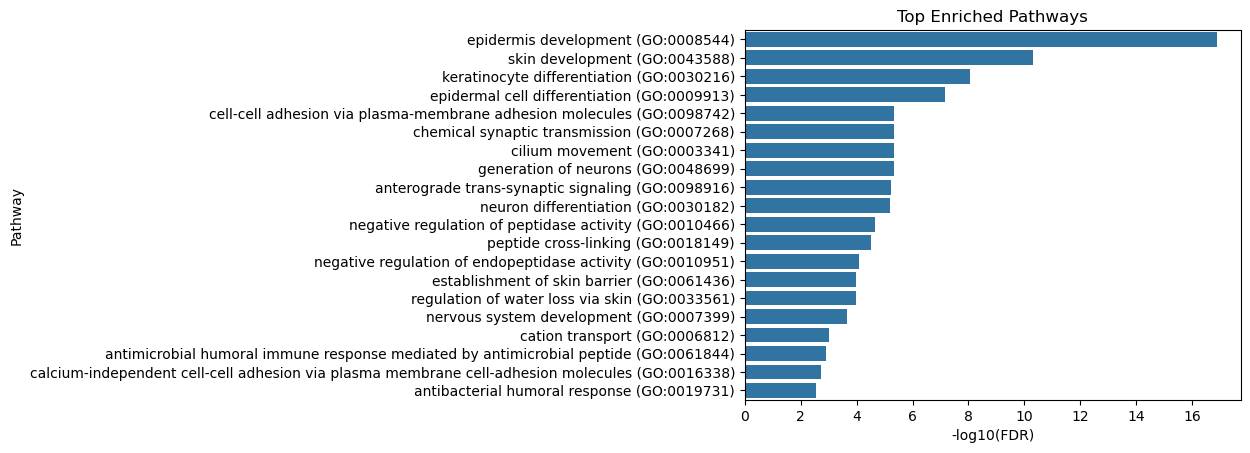

In [275]:
import seaborn as sns
import matplotlib.pyplot as plt

top = enr.results.head(20)
sns.barplot(y=top['Term'], x=-np.log10(top['Adjusted P-value']))
plt.title("Top Enriched Pathways")
plt.xlabel("-log10(FDR)")
plt.ylabel("Pathway")
plt.tight_layout()
plt.show()

In [337]:
path = "DeSeq2Local/results/DiseaseType_Subset_Lung/CancerSTtoST/squamous_cell_neoplasms_vs_adenomas_and_adenocarcinomas/sig_genes.csv"

In [338]:
sig_genes_info = pd.read_csv(path)

In [339]:
sig_genes_info

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,pvalue,padj
0,ENSG00000073282.14,13575.695052,-4.916965,0.130189,0.000000,0.000000
1,ENSG00000094796.5,446.430085,-5.995342,0.209455,0.000000,0.000000
2,ENSG00000110400.11,14787.796794,-3.215693,0.078794,0.000000,0.000000
3,ENSG00000114948.13,2964.990929,-5.355335,0.130170,0.000000,0.000000
4,ENSG00000121552.4,5638.927976,-4.371501,0.112297,0.000000,0.000000
...,...,...,...,...,...,...
3513,ENSG00000102891.4,0.370380,-9.419681,0.905005,0.034498,0.044980
3514,ENSG00000196341.3,2.654889,-1.136429,0.333924,0.034613,0.045120
3515,ENSG00000196224.7,0.300309,-2.617375,0.588778,0.035118,0.045743
3516,ENSG00000141750.7,42.948518,-1.165712,0.125298,0.036372,0.047316


In [340]:
sig_genes_info.index = sig_genes_info['Unnamed: 0']

In [341]:
sig_genes_info

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,pvalue,padj
Unnamed: 0,,,,,,
ENSG00000073282.14,ENSG00000073282.14,13575.695052,-4.916965,0.130189,0.000000,0.000000
ENSG00000094796.5,ENSG00000094796.5,446.430085,-5.995342,0.209455,0.000000,0.000000
ENSG00000110400.11,ENSG00000110400.11,14787.796794,-3.215693,0.078794,0.000000,0.000000
ENSG00000114948.13,ENSG00000114948.13,2964.990929,-5.355335,0.130170,0.000000,0.000000
ENSG00000121552.4,ENSG00000121552.4,5638.927976,-4.371501,0.112297,0.000000,0.000000
...,...,...,...,...,...,...
ENSG00000102891.4,ENSG00000102891.4,0.370380,-9.419681,0.905005,0.034498,0.044980
ENSG00000196341.3,ENSG00000196341.3,2.654889,-1.136429,0.333924,0.034613,0.045120
ENSG00000196224.7,ENSG00000196224.7,0.300309,-2.617375,0.588778,0.035118,0.045743


In [342]:
sig_genes_info.loc["ENSG00000063660.9"].log2FoldChange

np.float64(-2.84975051737269)

In [343]:
upregulated_intersection = []
downregulated_intersection = []
for gene_id in intersection_sig_genes:
    info = sig_genes_info.loc[gene_id]
    if info.log2FoldChange > 0:
        upregulated_intersection.append(gene_id)
    else:
        downregulated_intersection.append(gene_id)

In [345]:
len(upregulated_intersection) ## Associated with LUSC

1595

In [346]:
len(downregulated_intersection) ## Associated with LUAD

1554

In [347]:
mg = mygene.MyGeneInfo()
# Remove version numbers if needed
gene_ids = [gid.split('.')[0] for gid in upregulated_intersection]

# Query mygene.info
results = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol', species='human')

# Build dictionary
id_to_name_upregulated = {entry['query']: entry.get('symbol', None) for entry in results}

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [349]:
id_to_name_upregulated

1595

In [350]:
mg = mygene.MyGeneInfo()
# Remove version numbers if needed
gene_ids = [gid.split('.')[0] for gid in downregulated_intersection]

# Query mygene.info
results = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol', species='human')

# Build dictionary
id_to_name_downregulated = {entry['query']: entry.get('symbol', None) for entry in results}

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [352]:
id_to_name_downregulated

1554

In [353]:
df = pd.DataFrame(list(id_to_name_upregulated.items()), columns=['id', 'name'])
df = df[~df["name"].isna()]
df.to_csv("id_to_name_lung_upregulated_genes.csv")
df

,id,name
0,ENSG00000164161,HHIP
1,ENSG00000250799,PRODH2
2,ENSG00000166578,IQCD
3,ENSG00000196196,HRCT1
4,ENSG00000196350,ZNF729
...,...,...
1590,ENSG00000106992,AK1
1591,ENSG00000142025,DMRTC2
1592,ENSG00000253953,PCDHGB4
1593,ENSG00000181903,OR4C6


In [354]:
df = pd.DataFrame(list(id_to_name_downregulated.items()), columns=['id', 'name'])
df = df[~df["name"].isna()]
df.to_csv("id_to_name_lung_downregulated_genes.csv")
df

,id,name
0,ENSG00000188910,GJB3
1,ENSG00000187054,TMPRSS11A
2,ENSG00000185860,CCDC190
3,ENSG00000225899,FRG2B
4,ENSG00000105810,CDK6
...,...,...
1549,ENSG00000163975,MELTF
1550,ENSG00000114331,ACAP2
1551,ENSG00000188883,KLRG2
1552,ENSG00000162723,SLAMF9


In [1]:
overlap = set(list(id_to_name_upregulated.values())) & set(list(id_to_name_downregulated.values()))

if overlap:
    print(f"{len(overlap)} gene(s) appear in both lists:")
    print(overlap)
else:
    print("No overlap — the two lists are cleanly separated.")

NameError: name 'id_to_name_upregulated' is not defined